In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("telecom_churn.csv")

In [3]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [4]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Churn                int64
AccountWeeks         int64
ContractRenewal      int64
DataPlan             int64
DataUsage          float64
CustServCalls        int64
DayMins            float64
DayCalls             int64
MonthlyCharge      float64
OverageFee         float64
RoamMins           float64
dtype: object

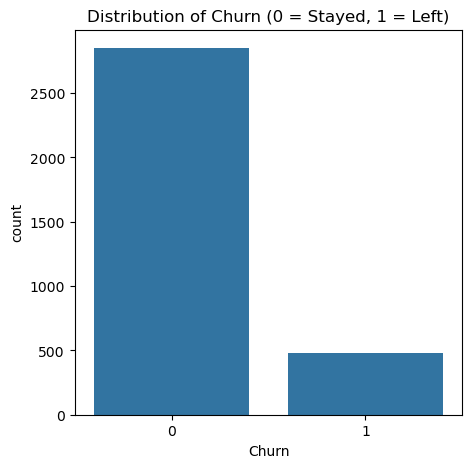

In [21]:
plt.figure(figsize=(5,5))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn (0 = Stayed, 1 = Left)')
plt.savefig('Bar Plot (Churn Count)')
plt.show()

This plot illustrates the count of customers who are still with the service (0) versus those who have left (1). It helps identify if there is a class imbalance in the dataset.

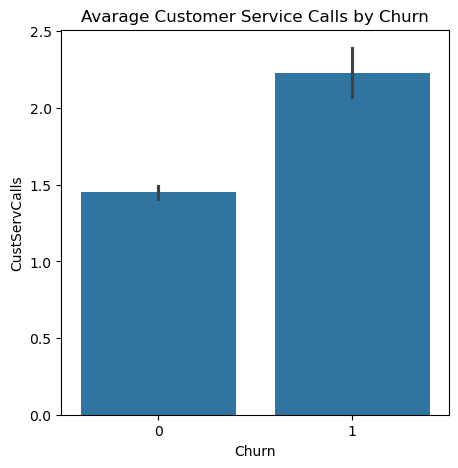

In [22]:
plt.figure(figsize=(5,5))
sns.barplot(data=df,x='Churn',y='CustServCalls')
plt.title ('Avarage Customer Service Calls by Churn')
plt.savefig('Bar Plot (CustServCalls vs Churn)')
plt.show()


This chart shows that customers who churned (Churn 1) made significantly more customer service calls on average. This suggests that dissatisfaction with service is a major driver of customer churn.

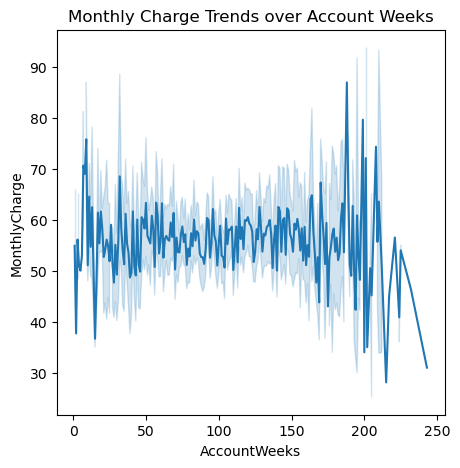

In [23]:
plt.figure(figsize=(5,5))
sns.lineplot(data=df, x='AccountWeeks', y='MonthlyCharge')
plt.title('Monthly Charge Trends over Account Weeks')
plt.savefig('Line Plot (AccountWeeks vs MonthlyCharge)')
plt.show()

This plot visualizes how the MonthlyCharge fluctuates based on the length of the customer’s tenure (AccountWeeks). it helps identify if long-term customers are being charged differently over time.

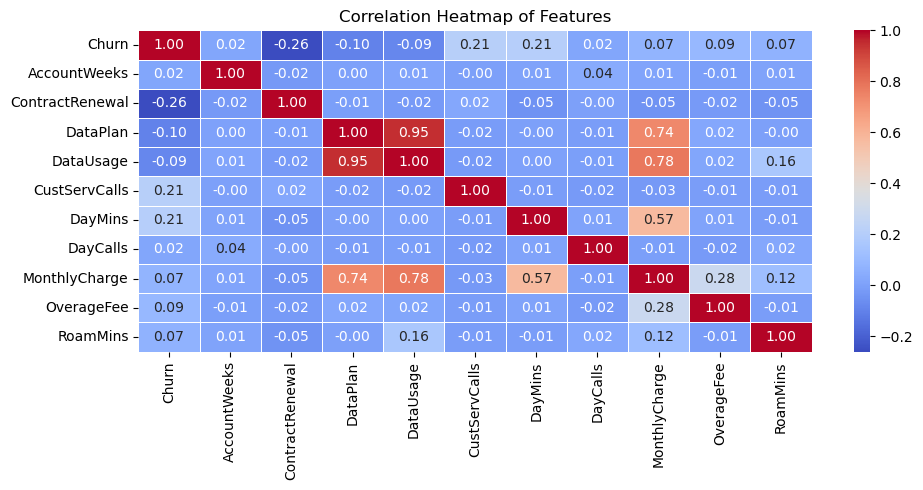

In [25]:
plt.figure(figsize=(10,5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.savefig('Heatmap (Correlation Matrix)')
plt.tight_layout()
plt.show()

The heatmap reveals the relationships between different variables. For instance, it confirms a strong positive correlation between DataUsage and MonthlyCharge, meaning as data usage increases, the bill typically goes up.
DataUsage and MonthlyCharge: A very strong positive correlation is often observed between these two variables. This indicates that as a customer's DataUsage increases, their MonthlyCharge also tends to rise significantly.

DayMins and MonthlyCharge: If the correlation value between these two is high, it signifies a direct relationship—meaning the more minutes a customer spends talking during the day (DayMins), the higher their MonthlyCharge will be.

Churn and CustServCalls: This is one of the most critical parts of the chart. A positive correlation (e.g., 0.20 or higher) between Churn and CustServCalls suggests that customers who make frequent complaints or service calls are much more likely to leave the service.

ContractRenewal and Churn: Typically, these two share a negative correlation. This means that customers who have recently renewed their contracts (ContractRenewal = 1) have a much lower probability of churning.

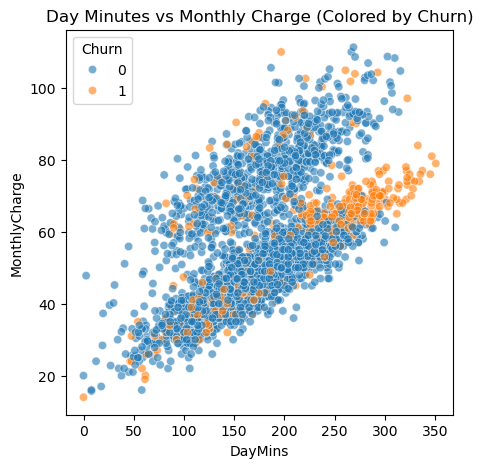

In [26]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, x='DayMins', y='MonthlyCharge', hue='Churn', alpha=0.6)
plt.title('Day Minutes vs Monthly Charge (Colored by Churn)')
plt.savefig('Scatter Plot (DayMins vs MonthlyCharge)')
plt.show()

This plot shows a direct relationship where higher daytime usage (DayMins) leads to a higher MonthlyCharge. By coloring the points by Churn, we can observe if high-paying customers are more likely to leave the service.